In [11]:
import pyMMF
import numpy as np
import matplotlib.pyplot as plt
import time

In [12]:
# Find modes of an MMF
NA = 0.1
radius = 12.5 # in microns
areaSize = 2.5*radius # calculate the field on an area larger than the diameter of the fiber
npoints = 2**7 # resolution of the window
n1 = 1.45
wl = 0.532 # wavelength in microns
curvature = None

profile = pyMMF.IndexProfile(npoints = npoints, areaSize = areaSize)
profile.initStepIndex(n1=n1, a=radius, NA=NA)

solver = pyMMF.propagationModeSolver()
solver.setIndexProfile(profile)
solver.setWL(wl)

NmodesMax = pyMMF.estimateNumModesSI(wl,radius,NA,pola = 1)

modes = solver.solve (mode = 'SI', curvature = None)
modes.sort() # sort modes by descending beta constants

2024-01-15 13:25:59,581 - pyMMF.core [DEBUG  ]  Debug mode ON.
2024-01-15 13:25:59,583 - pyMMF.solv [INFO   ]  Finding the propagation constant of step index fiber by numerically solving the dispersion relation.
2024-01-15 13:26:00,085 - pyMMF.solv [INFO   ]  Found 55 modes in 0.50 seconds.
2024-01-15 13:26:00,086 - pyMMF.solv [INFO   ]  Finding analytical LP mode profiles associated to the propagation constants.
2024-01-15 13:26:00,684 - pyMMF.solv [INFO   ]  Found 55 LP mode profiles in 0.0 minutes.
2024-01-15 13:26:00,686 - pyMMF.core [DEBUG  ]  Mode data stored in memory.


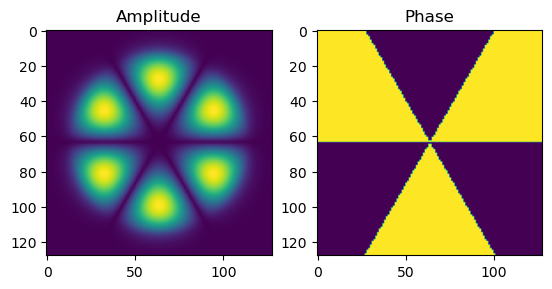

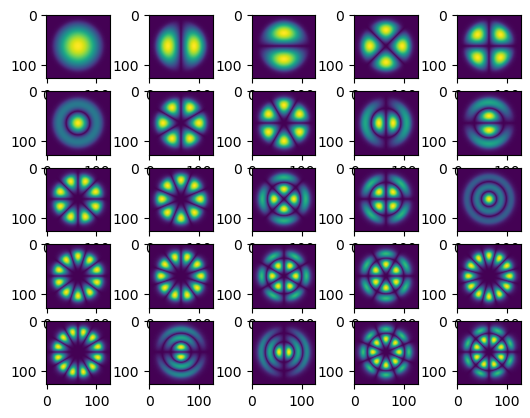

In [13]:
# Show example of mode number 'm'

m = 7
plt.figure()
plt.subplot(121)
plt.imshow(np.abs(modes.profiles[m]).reshape([npoints]*2))
plt.title('Amplitude')
plt.subplot(122)
plt.imshow(np.angle(modes.profiles[m]).reshape([npoints]*2))
plt.title('Phase')


# show first n modes to check order of sort
plt.figure()
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(np.abs(modes.profiles[i].reshape([npoints]*2)))
    

Vector of mode weights:
[-0.28616287-0.876844j   -0.65074667+0.29979291j  0.49403771+0.42363272j
 -0.31298352+0.07181219j  0.76129224-0.33009061j  0.01411962-0.56501504j
 -0.64523395+0.7411565j  -0.60067759+0.20242727j -0.49153724-0.80337638j
  0.2189395 +0.38887598j  0.67855677+0.04195739j  0.029132  +0.13956451j
 -0.06682047-0.14465137j -0.10774037+0.13258936j  0.04538528+0.11202486j
 -0.07059236+0.30050337j  0.67513138+0.05096899j -0.53465364+0.09663824j
 -0.83163895+0.41360724j -0.59530059-0.3629829j  -0.00147024+0.17709857j
  0.69562245-0.28725158j  0.37759778-0.06347529j  0.62866619+0.11096583j
 -0.20095435-0.0612268j  -0.43684141-0.71960705j -0.13390449-0.04297293j
 -0.33503422+0.07009503j  0.28022334+0.26385257j  0.04829113-0.10784453j
  0.80358652+0.03038668j -0.37774141-0.18310146j  0.22441857-0.04621937j
  0.66450348-0.53782978j  0.03661131+0.0703388j  -0.24221965+0.17836296j
  0.54006718+0.16715999j  0.49284741-0.27596925j -0.07873942-0.05974316j
  0.01774202+0.01240916j -0

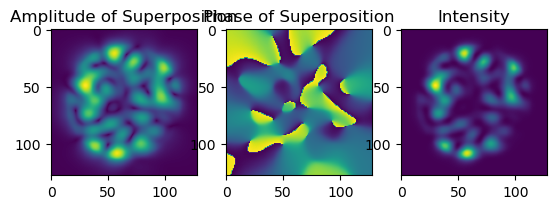

In [14]:
# Define random weights for all modes
a = np.random.uniform(0, 1, size=NmodesMax)
phi = np.random.uniform(0, 2 * np.pi, size=NmodesMax)
weights = a * np.exp(1j * phi)

print('Vector of mode weights:')
print(weights)

#Create Superposition
superpos = sum(weights[i] * modes.profiles[i] for i in range(NmodesMax))


# Calculate intensity in MMF
intensity = superpos * np.conj(superpos)
intensity = np.real(intensity) # only to change data type from complex to float

# Visualize the superposition
plt.figure()
plt.subplot(131)
plt.imshow(np.abs(superpos).reshape([npoints] * 2))
plt.title('Amplitude of Superposition')

plt.subplot(132)
plt.imshow(np.angle(superpos).reshape([npoints] * 2))
plt.title('Phase of Superposition')

plt.subplot(133)
plt.imshow(intensity.reshape([npoints] * 2))
plt.title('Intensity')

plt.show()

In [15]:
# Set the number of modes and generate a random complex matrix
random_matrix = np.random.rand(NmodesMax, NmodesMax) + 1j * np.random.rand(NmodesMax, NmodesMax)

# Perform Singular Value Decomposition (SVD)
U, S, V = np.linalg.svd(random_matrix)
TM = U
print("Random complex matrix U from SVD:")        
print(U)

Random complex matrix U from SVD:
[[-0.0951754 -0.08546277j  0.06821488-0.11747359j  0.04427299+0.08139473j
  ...  0.08769451+0.11528101j  0.14393419-0.05607769j
   0.02024638-0.07643501j]
 [-0.08823511-0.09908189j -0.02879811-0.03725046j -0.07645673+0.1615853j
  ... -0.02645947-0.01034578j -0.15408835+0.12783406j
   0.08935277+0.10059917j]
 [-0.09590758-0.08843536j  0.09090553+0.10711807j  0.00643693-0.03636738j
  ... -0.0212242 -0.10729817j  0.10885281+0.18292428j
  -0.12338505+0.03016178j]
 ...
 [-0.08823363-0.0956827j  -0.11217263-0.07134216j -0.07694263+0.04620362j
  ...  0.00593704+0.14690016j -0.08523872-0.08466921j
  -0.00743231-0.05632019j]
 [-0.10412463-0.09178638j  0.05069169-0.10800381j -0.10448968-0.10262096j
  ... -0.21948914-0.07409701j -0.04127605-0.10653403j
  -0.02610686-0.23758652j]
 [-0.1027565 -0.08579621j -0.04294566-0.05839376j  0.02439505-0.07039892j
  ...  0.01518065+0.06352058j -0.08063121-0.01336436j
   0.10364429+0.01211955j]]


In [29]:
# Number of modes in the few-mode fiber
#total_modes = 8

# Initialize the vector with zeros
#fiber_modes = np.zeros(total_modes, dtype=complex)

# Assign values for three modes (you can modify these values accordingly)
#fiber_modes[0] = 0.5 * np.exp(1j * np.pi/4)
#fiber_modes[3] = 0.8 * np.exp(1j * np.pi/3)
#fiber_modes[7] = 0.3 * np.exp(1j * np.pi/2)


total_modes = 6

# Create random amplitude and phase for few-mode-number of modes
a = np.random.uniform(0, 1, size=total_modes)
phi = np.random.uniform(0, 2 * np.pi, size=total_modes)
phi[0] = 0

# complex vector
fiber_modes_nn = a * np.exp(1j * phi)
fiber_modes_nn = fiber_modes_nn / np.linalg.norm(fiber_modes_nn)

# pad few-mode vector ro multimode vector
fiber_modes = np.pad(fiber_modes_nn, (0, NmodesMax - len(fiber_modes_nn)%1024), 'constant')

print("Multimode Fiber Modes:")
print(fiber_modes)

Multimode Fiber Modes:
[ 0.17758235+0.j         -0.36955798-0.28269604j  0.32362292-0.33424486j
  0.25819777-0.38296076j -0.27335028-0.43640123j  0.03093536-0.23680054j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0

In [30]:
# Calculate the MMF output vector y as y = TM * x
#y = np.dot(TM, x)
y = np.dot(fiber_modes, TM)

# Display the results
print("\n Random complex vector x:")
print(fiber_modes)
print("\n MMF output vector y:")
print(y)



 Random complex vector x:
[ 0.17758235+0.j         -0.36955798-0.28269604j  0.32362292-0.33424486j
  0.25819777-0.38296076j -0.27335028-0.43640123j  0.03093536-0.23680054j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j          0.        +0.j
  0.        +0.j          0.        +0.j       

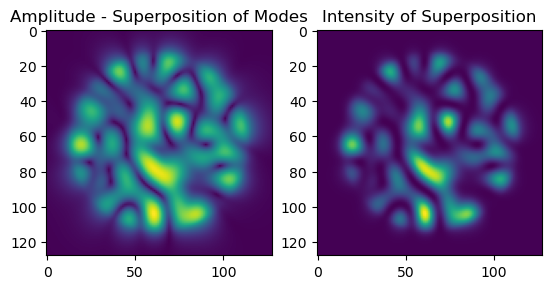

In [31]:
# Superposition of modes
superpos = sum(y[i] * modes.profiles[i] for i in range(NmodesMax))

plt.subplot(121)
plt.imshow(np.abs(superpos).reshape([npoints] * 2), cmap='viridis')
plt.title('Amplitude - Superposition of Modes')

# Calculate the intensity
intensity = np.abs(superpos) ** 2
plt.subplot(122)
plt.imshow(intensity.reshape([npoints]*2), cmap='viridis')
plt.title('Intensity of Superposition')


plt.show()
